In [1]:
import pandas as pd
import numpy as np
import math
import catboost
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier


## Метрика

In [2]:
def ndcg_at_k(rel, k=5):
    """DCG@k для бинарной релевантности (0/1)"""
    top_k = rel[:k]
    dcg = sum(1.0 / math.log2(i+2) for i, g in enumerate(top_k) if g == 1)

    ideal_rel = sorted(rel, reverse=True)[:k]
    idcg = sum(1.0 / math.log2(i+2) for i, g in enumerate(ideal_rel) if g == 1)

    return dcg / idcg if idcg > 0 else np.nan

def mean_ndcg_at_5(df, request_col='request_id', score_col='score', target_col='is_deal'):
    """
    Вычисляет средний NDCG@5 по всем request_id в датафрейме.

    Параметры
    ----------
    df : pd.DataFrame
    Колонки: request_id, deal, score, target (0/1).
    Для каждого request_id может быть от 1 до 50 строк (предложений),
    и ровно одна строка с target=1 (покупка).
    request_col : str
    score_col : str
    target_col : str

    Возврат
    -------
    float : средний NDCG@5
    """
    # Сортируем внутри каждого request_id по убыванию скоров модели
    df_sorted = df.sort_values([request_col, score_col], ascending=[True, False])

    # Группируем и считаем NDCG@5
    ndcg_per_request = df_sorted.groupby(request_col)[target_col].apply(
    lambda x: ndcg_at_k(x.tolist(), k=5)
    )
    return np.nanmean(ndcg_per_request)

# Выгрузка выборки

In [3]:
df_train = pd.read_parquet('data/train_dataset_small.pq')
df_features = pd.read_parquet('data/features_small.pq')
df_test = pd.read_parquet('data/test_dataset_small.pq')

In [ ]:
df_train.columns

In [ ]:
len(df_train)

In [ ]:
df_train.columns.difference(df_features.columns)

In [ ]:
df_train['app_id'].nunique(), df_train['request_id'].nunique(), df_train['app_id'].iloc[0], 

In [ ]:
(df_train['app_id'] == '10027584851').sum()

In [10]:
df_train[df_train['app_id'] == '10027584851'].head()


,app_id,request_received,date_part,request_id,req_loan_amount,req_term,verif_compl,offer_id,variant_no,offer_type,...,term,limit,risk_level_map,eva,eva_perc,verif_need,need_2ndfl,ncl,channel,basket_name
13,10027584851,2026-02-12 16:37:56.741739,2026-02-12,4854545000000000000de84d5211e16b0000000000005a94,30000000.0,60,N,472,32,RA,...,24,30000000.0,MR,31395.6889600000000000,0.0966780000000000,N,D,0.0545806700000000,Internet,NaN
344022,10027584851,2026-02-12 16:37:56.741739,2026-02-12,4854545000000000000de84d5211e16b0000000000005a94,30000000.0,60,N,352,10,RA,...,60,30000000.0,MR,44856.9440420000000000,0.0658260000000000,N,D,0.1397460900000000,Internet,NaN
370422,10027584851,2026-02-12 16:37:56.741739,2026-02-12,4854545000000000000de84d5211e16b0000000000005a94,30000000.0,60,N,296,2,RA,...,48,30000000.0,MR,50208.5480340000000000,0.0827650000000000,N,D,0.1088443900000000,Internet,NaN
576105,10027584851,2026-02-12 16:37:56.741739,2026-02-12,4854545000000000000de84d5211e16b0000000000005a94,30000000.0,60,N,276,25,PL,...,36,33000000.0,MR,33300.9775090000000000,0.0865020000000000,N,D,0.0860369500000000,Internet,NaN
671840,10027584851,2026-02-12 16:37:56.741739,2026-02-12,4854545000000000000de84d5211e16b0000000000005a94,30000000.0,60,N,324,5,RA,...,48,30000000.0,MR,46501.3581420000000000,0.0776290000000000,N,D,0.1179635000000000,Internet,NaN


In [ ]:
df_train['term'].value_counts()

In [ ]:
constant_columns_train = [col for col in df_train.columns if (df_train[col].value_counts().iloc[0] / len(df_train[col])) > 0.99]
df_features.fillna('none')
constant_columns_features = [col for col in df_features.columns if (df_features[col].value_counts().iloc[0] / len(df_features[col])) > 0.99]
constant_columns_test = [col for col in df_test.columns if (df_test[col].value_counts().iloc[0] / len(df_test[col])) > 0.999]

print(constant_columns_train)
print(constant_columns_features)
print(constant_columns_test)

In [ ]:
df_train.describe()


In [ ]:
df_train.duplicated().sum()

In [ ]:
df_train.drop(columns=constant_columns_train, inplace=True)
df_features.drop(columns=constant_columns_features, inplace=True)
df_test.drop(columns=constant_columns_test, inplace=True)

In [ ]:
df_train[['request_received', 'req_loan_amount', 'req_term', 'offer_id', 'variant_no', 'pil1mtrx_offer', 'is_deal', 'term', 'limit']].corr()

In [ ]:
df_train['risk_level_map'].value_counts()

In [ ]:
df_train['ncl'].value_counts()

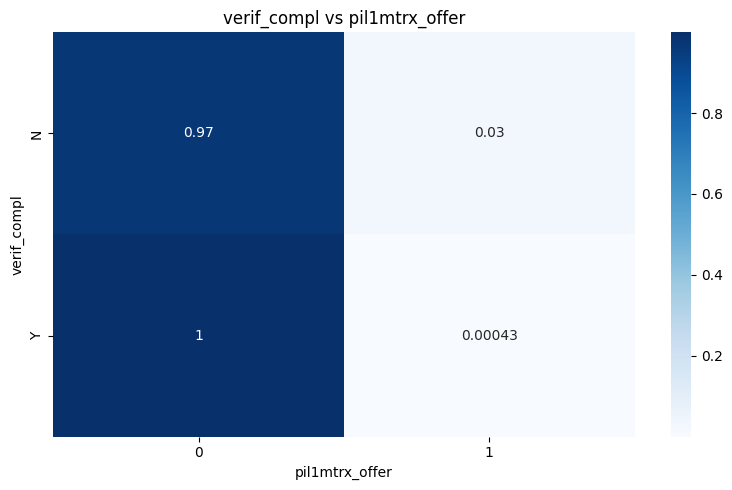

In [18]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

cross = pd.crosstab(
    df_train['verif_compl'],
    df_train['pil1mtrx_offer'],
    normalize='index'
)

plt.figure(figsize=(8, 5))

sns.heatmap(
    cross,
    annot=True,
    cmap='Blues'
)

plt.title('verif_compl vs pil1mtrx_offer')

plt.tight_layout()
plt.show()

In [11]:
df_train['request_received'] = pd.to_datetime(df_train['request_received'])

print(df_train['request_received'].min())
print(df_train['request_received'].max())

2026-01-01 06:01:48.349287
2026-03-14 23:54:40.120622


In [12]:
df_test['request_received'] = pd.to_datetime(df_test['request_received'])

print(df_test['request_received'].min())
print(df_test['request_received'].max())

2026-01-01 22:09:24.691517
2026-03-30 22:50:55.710718


In [14]:
'worksalary_rur_amt' in df_train.columns

False

In [ ]:
d = df_features.columns

part = 30 * 0

for idx, item in enumerate(d, start=1):
    print(f'{idx}: {item}')

1: app_id
2: date_part
3: invest_rur_amt
4: clientsegment
5: active_claim_flag
6: blacklist_employer_flag
7: asmart_sub_inactive_days
8: primarybank_out_flag
9: country
10: clienttype
11: life_time_days
12: clientgroup
13: age
14: tz_msk_timedelta
15: asmart_sub_active_flag
16: clientoutflowstatus
17: srvpackage_fst
18: profit_income_out_rur_amt_cm
19: nonresident_flag
20: izk_new_flag
21: r700_flag
22: asmart_extra_sub_active_3m_days
23: compensation_rur_amt_sum_1y
24: clientsegment_grace_flag
25: asmart_sub_active_6m_days
26: compensation_rur_amt_sum_2y
27: r200_flag
28: status_period_cnt
29: curbal_usd_amt_cm_avg
30: clientsegment_prd


In [ ]:
df_train.groupby(
    ['verif_compl', 'pil1mtrx_offer']
)['eva'].mean()

In [ ]:
import seaborn as sns

sns.pairplot(df_train.iloc[:1000])

In [ ]:
df_train.groupby('risk_level_map')['eva'].mean()

In [ ]:
[col for col in df_test.columns if df_test[col].isnull().any()]

In [ ]:
df_train['basket_name'].value_counts()

In [ ]:
df_train[['verif_compl', 'verif_need', 'need_2ndfl']].value_counts()

In [17]:
import pandas as pd

pd.set_option('display.max_rows', None)

In [ ]:
df_train[df_train['basket_name'].notnull()][['basket_name', 'verif_compl', 'verif_need', 'need_2ndfl']].value_counts()

In [ ]:
df_train[df_train['basket_name'].isna()][['verif_compl', 'verif_need', 'need_2ndfl']].value_counts()

In [ ]:
int(df_train['limit'].max())


In [ ]:
len(df_train[(df_train['basket_name'].notnull())]) - len(df_train[(df_train['basket_name'].notnull()) & (df_train['is_deal'] == 1)])

In [15]:
features = [
    "req_loan_amount",
    "req_term",
    "verif_compl",
    "variant_no",
    "offer_type",
    "pil1mtrx_offer",
    "is_deal",
    "rate",
    "term",
    "limit",
    "risk_level_map",
    "eva",
    "eva_perc",
    "verif_need",
    "need_2ndfl",
    "ncl",
    "channel",
    "basket_name",
]

df_train[(df_train['basket_name'].notnull())][features].value_counts(), len(df_train[(df_train['basket_name'].notnull())]), len(df_train[(df_train['basket_name'].notnull())]) - df_train[(df_train['basket_name'].notnull())][features].nunique()

(req_loan_amount  req_term  verif_compl  variant_no  offer_type  pil1mtrx_offer  is_deal  rate                 term  limit        risk_level_map  eva                      eva_perc            verif_need  need_2ndfl  ncl                 channel   basket_name                             
 35000000.0       60        N            1           PL          0               0        27.9900000000000000  36    45500000.0   LR              24154.8613270000000000   0.0392040000000000  N           D           0.0620552700000000  Internet  noverifdocmaxlimit                          1
 70000000.0       24        N            21          PL          0               0        26.9900000000000000  60    80500000.0   LR              46770.3170980000000000   0.0343750000000000  N           N           0.1190002900000000  Internet  noverifdocmaxlimit                          1
 35000000.0       36        N            9           RA          0               0        22.9900000000000000  60    45500000.0   VL

In [ ]:
df_train[df_train['basket_name'].notnull()].head()

In [ ]:
df_train[(df_train['app_id'] == '10027188533')]

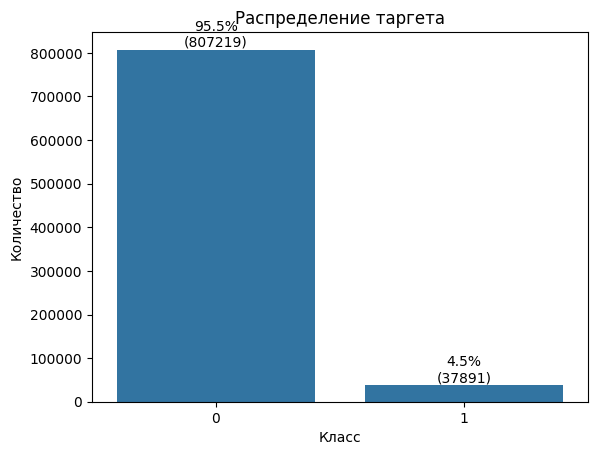

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

target = 'is_deal'

ax = sns.countplot(data=df_train, x=target)

total = len(df_train)

for p in ax.patches:
    count = int(p.get_height())
    percent = 100 * count / total
    
    ax.annotate(
        f'{percent:.1f}%\n({count})',
        (p.get_x() + p.get_width() / 2, p.get_height()),
        ha='center',
        va='bottom'
    )

plt.title('Распределение таргета')
plt.xlabel('Класс')
plt.ylabel('Количество')

plt.show()

In [ ]:
df_train['offer_id'].describe()

In [ ]:
df_train[df_train['app_id'] == '10027584851'][['request_received','date_part','request_id', 'offer_id']].nunique()

In [ ]:
df_train.columns

# Пример формирования выборки

In [ ]:
df_train = pd.merge(df_train, df_features, on=['app_id', 'date_part'])
df_test = pd.merge(df_test, df_features, on=['app_id', 'date_part'])

target = 'is_deal'


columns_to_drop = ['app_id', 'request_received', 'date_part', target]
features = ['req_loan_amount', 'req_term', 'limit', 'term']+['age']

request_ids = np.array(df_train.request_id.unique())

request_id_train, request_id_val = train_test_split(request_ids, test_size=0.2, random_state=42)
train = df_train[df_train.request_id.isin(request_id_train)]
val = df_train[df_train.request_id.isin(request_id_val)]

X_train = train[features].fillna(0)
X_val = val[features].fillna(0)

y_train = train[target]
y_val = val[target]

# Пример обучения модели

In [ ]:
rf_model = RandomForestClassifier(n_estimators=100,max_depth=5, random_state=42, n_jobs=-1)

# Train the model
print("Training RandomForestClassifier...")
rf_model.fit(X_train, y_train)
print("Training complete.")

In [ ]:
train.loc[:, 'score'] = rf_model.predict_proba(X_train.loc[:, :])[:, 1]
val.loc[:, 'score'] = rf_model.predict_proba(X_val.loc[:, :])[:, 1]


print(f"NDCG@5 на обучении {mean_ndcg_at_5(train)}")

print(f"NDCG@5 на валидации {mean_ndcg_at_5(val)}")

In [ ]:
import numpy as np
import pandas as pd
import math

from sklearn.model_selection import train_test_split
from lightgbm import LGBMRanker

In [ ]:
df_train = pd.merge(df_train, df_features, on=['app_id', 'date_part'], how='left')
df_test = pd.merge(df_test, df_features, on=['app_id', 'date_part'], how='left')

target = 'is_deal'
group_col = 'request_id'

In [ ]:
columns_to_drop = ['app_id', 'request_received', 'date_part', target]
features = ['req_loan_amount', 'req_term', 'limit', 'term']+['age']

for df in [df_train, df_test]:
    df['limit_to_req'] = df['limit'] / (df['req_loan_amount'] + 1)
    df['term_to_req'] = df['term'] / (df['req_term'] + 1)
    df['limit_diff'] = df['limit'] - df['req_loan_amount']
    df['term_diff'] = df['term'] - df['req_term']

features += [
    'limit_to_req',
    'term_to_req',
    'limit_diff',
    'term_diff'
]

In [ ]:
use_cols = features + [target, group_col, 'app_id', 'offer_id']

df_small = df_train[use_cols].copy()

In [ ]:
request_ids = np.array(df_small[group_col].unique())
# request_ids = np.array(df_train.request_id.unique())
request_id_train, request_id_val = train_test_split(
    request_ids,
    test_size=0.2,
    random_state=42
)

train_mask = df_small[group_col].isin(request_id_train)
val_mask = df_small[group_col].isin(request_id_val)

train = df_small.loc[train_mask].sort_values(group_col).reset_index(drop=True)
val = df_small.loc[val_mask].sort_values(group_col).reset_index(drop=True)

In [ ]:
# важно для LGBMRanker
train = train.sort_values(group_col).reset_index(drop=True)
val = val.sort_values(group_col).reset_index(drop=True)

X_train = train[features].fillna(0).astype('float32')
X_val = val[features].fillna(0).astype('float32')

y_train = train[target].astype('int8')
y_val = val[target].astype('int8')

train_group = train.groupby(group_col, sort=False).size().values
val_group = val.groupby(group_col, sort=False).size().values

In [ ]:
ranker = LGBMRanker(
    objective='lambdarank',
    metric='ndcg',
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    max_depth=-1,
    min_child_samples=20,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)

print("Training LGBMRanker...")

ranker.fit(
    X_train,
    y_train,
    group=train_group,
    eval_set=[(X_val, y_val)],
    eval_group=[val_group],
    eval_at=[5]
)

print("Training complete.")

In [ ]:
train['score'] = ranker.predict(X_train)
val['score'] = ranker.predict(X_val)

print(f"NDCG@5 на обучении {mean_ndcg_at_5(train)}")
print(f"NDCG@5 на валидации {mean_ndcg_at_5(val)}")

#1
NDCG@5 на обучении 0.5740317003290595
NDCG@5 на валидации 0.5679099928172667

№2 lambdamart
NDCG@5 на обучении 0.7548347484216901
NDCG@5 на валидации 0.7459085607927813




# Commit

In [ ]:
df_test.loc[:, 'score'] = rf_model.predict_proba(df_test[features].fillna(0))[:, 1].round(6)

In [ ]:
answer_cols = ['request_id', 'variant_no', 'score']
df_test[answer_cols].to_csv('commit.csv', sep=';',index=False)

In [ ]:
# сортировка обязательна для ranker
df_test = df_test.sort_values('request_id').reset_index(drop=True)

# предикт
df_test.loc[:, 'score'] = ranker.predict(
    df_test[features].fillna(0).astype('float32')
).round(6)

# сабмит
answer_cols = ['request_id', 'variant_no', 'score']

df_test[answer_cols].to_csv(
    'commit.csv',
    sep=';',
    index=False
)

print('submission saved -> commit.csv')